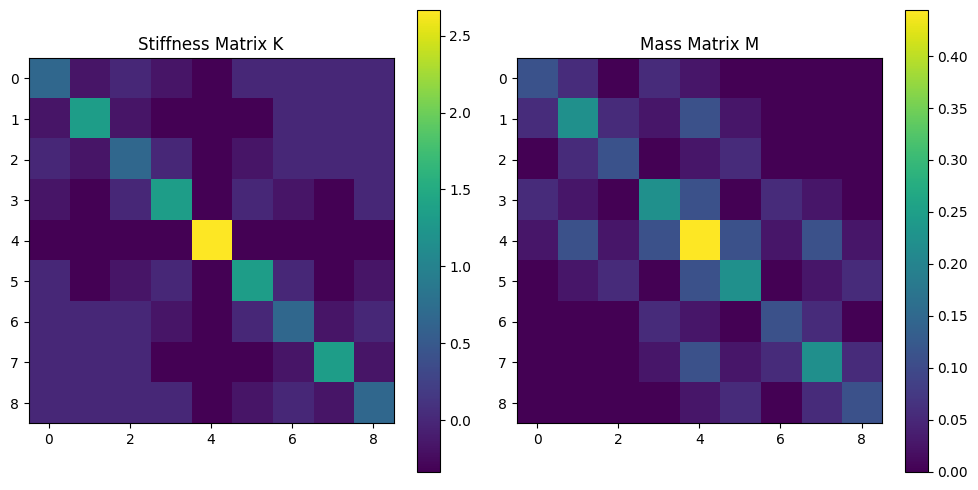

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import finitewave as fw

n = 2
size = 2
elem_type = fw.ElementType.QUAD

coords, elems = fw.build_quadrilateral_plane(n, n, (0, size), (0, size))

tissue = fw.CardiacTissue(coords=coords, elems=elems, elem_type=elem_type)
spatial_discr = fw.FiniteElementDiscretization()
K, M = spatial_discr.compute_weights(tissue)

fig, axs = plt.subplots(1, 2, figsize=(10, 5))
axs[0].set_title("Stiffness Matrix K")
im0 = axs[0].imshow(K.toarray(), cmap='viridis')
axs[1].set_title("Mass Matrix M")
im1 = axs[1].imshow(M.toarray(), cmap='viridis')
plt.colorbar(im0, ax=axs[0])
plt.colorbar(im1, ax=axs[1])
plt.tight_layout()
plt.show()

Running AlievPanfilov on Quadrilateral Elements: 100%|██████████| 100/100 [00:00<00:00, 1361.38it/s]


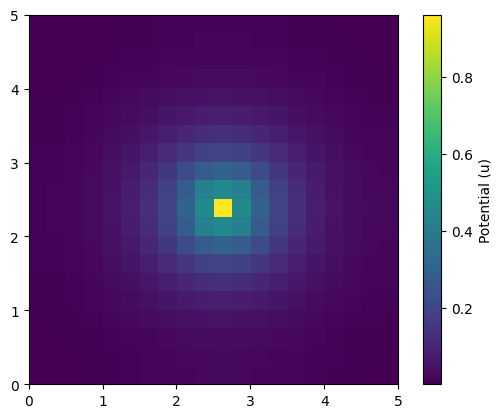

In [7]:
import numpy as np
import pyvista as pv
import finitewave as fw


# create a tissue of size 50x50 with 200x200 points:
n = 20
size = 5
elem_type = fw.ElementType.QUAD

coords, elems = fw.build_quadrilateral_plane(n-1, n-1, (0, size), (0, size))

# create cardiac tissue object:
tissue = fw.CardiacTissueElements(coords, elems, elem_type=elem_type)

# set up stimulation parameters:
stim_sequence = fw.StimSequence()

stim_sequence.add_stim(fw.StimCurrentCoord(time=0, curr_value=20, duration=5,
                                           x_min=2.4, x_max=2.7,
                                           y_min=2.4, y_max=2.7))

# create model object and set up parameters:
simulation = fw.CardiacSimulation(dt=0.01, t_max=1.0, backend="numba")
# add the tissue and the stim parameters to the model object:
simulation.cardiac_tissue = tissue
simulation.cardiac_model = fw.AlievPanfilov()
simulation.stim_sequence = stim_sequence
# Set up time integration. Backward Euler is used by default:
# ! Forward Euler is conditionally stable for quadrilateral meshes
simulation.time_integration = fw.ForwardEulerTimeIntegration(reaction_lumping=True)

# run the model:
simulation.run()

# get the resulting potential at the element centers:
u = simulation.cardiac_model.u

%matplotlib inline
plt.imshow(u.reshape((n, n)), extent=(0, size, 0, size))
plt.colorbar(label='Potential (u)')
plt.show()


In [72]:
import numpy as np


def average_method(x, y):
    return 0.5 * (x + y)


def connectivity_along_axis(connectivity, ijk, mask, axis):

    connectivity = np.asarray(connectivity)
    ndim, n_points = ijk.shape

    if connectivity.size == 1:
        return np.atleast_1d(connectivity)
    if connectivity.shape == (ndim,):
        return np.atleast_1d(connectivity[axis])
    if connectivity.shape == (n_points, ndim):
        connectivity_along_axis = connectivity[:, axis].copy()
        connectivity_along_axis[mask == 0] = 0.
        return connectivity_along_axis
    
    raise ValueError(f"Connectivity must be a scalar," + 
                         f" a 1D array of length {ndim}," + 
                         f" or a 2D array of shape ({n_points}, {ndim}).")


def diffusion_along_axis(diffusion, ijk_neighbor, mask, axis, tissue_index_map):
    diffusion = np.atleast_1d(diffusion)
    ndim, n_points = ijk_neighbor.shape
    if diffusion.size == 1:
        return diffusion * np.eye(ndim)[axis]

    if diffusion.shape == (n_points, ndim, ndim):
        neighbor_indexes = tissue_index_map[*ijk_neighbor[:, mask > 0]]
        d_axis = average_method(diffusion[mask > 0, axis, :],
                                diffusion[neighbor_indexes, axis, :])

        d_full = np.zeros((n_points, ndim))
        d_full[mask > 0] = d_axis
        return d_full

    raise ValueError(f"Diffusion must be constant or a 3D array of shape"  + 
                     f" ({n_points}, {ndim}, {ndim}).")

mesh = np.ones((200, 200, 200))
ijk = np.array(np.where(mesh > 0))
tissue_index_map = np.arange(mesh.size).reshape(mesh.shape)
ijk_neighbor = ijk.copy()
ijk_neighbor[0] += 1  # Shift neighbor in x-direction
mask = ijk_neighbor[0] < mesh.shape[0]

# d = np.repeat(np.eye(3)[np.newaxis, :, :], mesh.size, axis=0)  # Example diffusion tensor
d = 1.
# connectivity = np.ones((mesh.size, mesh.ndim))  # Example connectivity
connectivity = 0.5
# connectivity = np.ones(mesh.ndim)  # Example connectivity
# connectivity[0] = 0.5


diffusion_tensor = diffusion_along_axis(d, ijk_neighbor, mask, axis=0, tissue_index_map=tissue_index_map)
connectivity_tensor = connectivity_along_axis(connectivity, ijk, mask, axis=0)

diffusion_tensor * connectivity_tensor[:, None]

# res
# %timeit diffusion_component_local(d, connectivity, ijk, ijk_neighbor, mask, axis=1, tissue_index_map=tissue_index_map)

array([[0.5, 0. , 0. ]])

In [13]:
import numpy as np
import jax.numpy as jnp
import jax


def is_valid_index(index, mesh):
    limits = np.array(mesh.shape)[:, None]
    valid = np.all((index >= 0) & (index < limits), axis=0)
    valid[valid] = (mesh[tuple(index[:, valid])] > 0)
    return valid


@jax.jit
def is_valid_index_jit(index, mesh):
    limits = jnp.array(mesh.shape)
    is_valid = jnp.all((index >= 0) & (index < limits))
    return jnp.where(is_valid, mesh[tuple(index)] > 0, False)
    


@jax.jit
def is_valid_indexes_jit(index, mesh):
    mask = jax.vmap(is_valid_index_jit, in_axes=(1, None))(index, mesh)
    return mask


mesh = np.load("/Users/arstanbekokenov/Projects/Fibrowave/simulations/data/PID09/segment/seg_mesh.npy")
indexes = np.array(np.where(mesh > 0))
indexes[0] = indexes[0] + 1
indexes = jnp.array(indexes)
mesh = jnp.array(mesh)

is_valid_indexes_jit(indexes, mesh)

%timeit is_valid_indexes_jit(indexes, mesh)

2.95 ms ± 105 μs per loop (mean ± std. dev. of 7 runs, 100 loops each)


In [ ]:
from numba import njit, prange
from numpy.strings import index


@njit
def is_valid_index(index, limits, mesh):
    flat_index = 0
    for axis in range(mesh.ndim):
        coord = index[axis]
        limit = limits[axis]
        if coord < 0 or coord >= limit:
            return False
        flat_index = flat_index * limit + coord
    return mesh.flat[flat_index] > 0


@njit(parallel=True)
def is_valid_indexes_numba(indexes, mesh):
    n_points = indexes.shape[1]
    n_dims = indexes.shape[0]
    limits = np.array(mesh.shape)
    mask = np.zeros(n_points, dtype=np.bool_)
    for i in prange(n_points):
        index = indexes[:, i]
        mask[i] = is_valid_index(index, limits, mesh)
    return mask


mesh = np.load("/Users/arstanbekokenov/Projects/Fibrowave/simulations/data/PID09/segment/seg_mesh.npy")
indexes = np.array(np.where(mesh > 0))
indexes[0] = indexes[0] + 1
limits = np.array(mesh.shape)
mask = np.zeros(indexes.shape[1], dtype=bool)

is_valid_indexes_numba(indexes, mesh)

%timeit is_valid_indexes_numba(indexes, mesh)

2.52 ms ± 16.5 μs per loop (mean ± std. dev. of 7 runs, 100 loops each)


In [43]:
@njit
def ravel_multi_index_numba(multi_index, shape):
    flat_index = 0
    for axis in range(len(shape)):
        flat_index = flat_index * shape[axis] + multi_index[axis]
    return flat_index


ravel_multi_index_numba(np.array([1, 2]), np.array([3, 4]))  # should return 6

6

In [42]:
m = np.array([[0, 1], [1, 1], [0, 1]])
inds = np.array(np.where(m > 0))
inds[0] = inds[0] + 1

print(m)
print(inds)
is_valid_indexes_numba(inds, m)

[[0 1]
 [1 1]
 [0 1]]
[[1 2 2 3]
 [1 0 1 1]]


array([ True, False,  True, False])

In [1]:
import numpy as np
from numba import njit, prange


@njit(parallel=True, fastmath=True, cache=True)
def dot_numba(x, y):
    n = x.shape[0]
    s = 0.
    for i in prange(n):
        s += x.flat[i] * y.flat[i]
    return s

@njit(parallel=True, fastmath=True, cache=True)
def dot_numpy(x, y):
    return np.dot(x, y)


x = np.random.rand(10_000_000)
y = np.random.rand(10_000_000)

res = dot_numba(x, y)
res_np = dot_numpy(x, y)
res_np2 = np.dot(x, y)

print("Numba result:", res)
print("NumPy result:", res_np)
print("NumPy result 2:", res_np2)

%timeit dot_numba(x, y)
%timeit dot_numpy(x, y)
%timeit np.dot(x, y)

Numba result: 2499626.815416168
NumPy result: 2499626.815416166
NumPy result 2: 2499626.8154161703
843 μs ± 8.18 μs per loop (mean ± std. dev. of 7 runs, 1,000 loops each)
862 μs ± 14.9 μs per loop (mean ± std. dev. of 7 runs, 1,000 loops each)
2.91 ms ± 548 μs per loop (mean ± std. dev. of 7 runs, 100 loops each)


In [ ]:
@njit(parallel=True, fastmath=True, cache=True)
def ax_p_by(x, y, a, b):
    return a * x + b * y


@njit(parallel=True, fastmath=True, cache=True)
def ax_p_by_inplace(x, y, a, b):
    n = x.shape[0]
    for i in prange(n):
        x.flat[i] = a * x.flat[i] + b * y.flat[i]
    return x

ax_p_by(x, y, 2.0, 3.0)
ax_p_by_inplace(x, y, 2.0, 3.0)

%timeit ax_p_by(x, y, 2.0, 3.0)
%timeit ax_p_by_inplace(x, y, 2.0, 3.0)

2.86 ms ± 79.9 μs per loop (mean ± std. dev. of 7 runs, 100 loops each)
1.2 ms ± 1.49 μs per loop (mean ± std. dev. of 7 runs, 1,000 loops each)


In [5]:
@njit(parallel=True, fastmath=True, cache=True)
def y_pm_ax(xp, yp, xm, ym, a):
    n = xp.shape[0]
    for i in prange(n):
        yp.flat[i] += a * xp.flat[i]
        ym.flat[i] -= a * xm.flat[i]
    return yp, ym


@njit(parallel=True, fastmath=True, cache=True)
def y_p_ax(xp, yp, a):
    n = xp.shape[0]
    for i in prange(n):
        yp.flat[i] += a * xp.flat[i]
    return yp


@njit(parallel=True, fastmath=True, cache=True)
def y_m_ax(xm, ym, a):
    n = xm.shape[0]
    for i in prange(n):
        ym.flat[i] -= a * xm.flat[i]
    return ym


xp = np.random.rand(10_000_000)
yp = np.random.rand(10_000_000)
xm = np.random.rand(10_000_000)
ym = np.random.rand(10_000_000)

y_pm_ax(xp, yp, xm, ym, 2.0)
y_p_ax(xp, yp, 2.0)
y_m_ax(xm, ym, 2.0)

%timeit y_pm_ax(xp, yp, xm, ym, 2.0)
%timeit y_p_ax(xp, yp, 2.0)
%timeit y_m_ax(xm, ym, 2.0)

2.35 ms ± 35.6 μs per loop (mean ± std. dev. of 7 runs, 100 loops each)
1.19 ms ± 14.1 μs per loop (mean ± std. dev. of 7 runs, 1,000 loops each)
1.18 ms ± 1.53 μs per loop (mean ± std. dev. of 7 runs, 1,000 loops each)


In [1]:
import numpy as np
import finitewave as fw

mesh = np.load("/Users/arstanbekokenov/Projects/Finitewave/docs/examples/data/mesh.npy")

tissue = fw.CardiacTissueGrid(mesh.shape, dr=0.2)
tissue.mesh = mesh
tissue.mesh += (np.random.rand(*mesh.shape) < 0.2).astype(mesh.dtype)
tissue.mesh[mesh == 0] = 0

diffusion_model = fw.DiffusionModel()
K, M = diffusion_model.compute_weights(tissue)

In [4]:
def compute_diffusion_tensor(mesh, D_ac, D_al, fibers):
    if fibers is None:
        tissue_shape = mesh[mesh > 0].shape
        diffusion_tensor = np.zeros(tissue_shape + (mesh.ndim,))
        for i in range(mesh.ndim):
            diffusion_tensor[..., i, i] = 1

        return diffusion_tensor

    outer_product = np.einsum('ij,ik->ijk', fibers, fibers, optimize='optimal')
    diffusion_tensor = D_ac * np.eye(3) + (D_al - D_ac) * outer_product
    return diffusion_tensor


compute_diffusion_tensor(mesh, 1/9, 1, None).nbytes
# %timeit compute_diffusion_tensor(mesh, 1/9, 1, None)

160298616

In [6]:
from numba import njit, prange

@njit(parallel=True, fastmath=True, cache=True)
def matvec_p_ay_numba(indptr, indices, data, x, a, y, out):
    """
    Computes out = A @ x + a * y for a sparse matrix A in CSR format.

    Note: The A should be in global indexing
    """
    n_rows = indptr.shape[0] - 1

    for i in prange(n_rows):
        start, end = indptr[i], indptr[i+1]
        if start == end:
            continue
        a_x = 0.0
        for j in range(start, end):
            jj = indices[j]
            a_x += data[j] * x.flat[jj]

        out.flat[i] = a_x + a * y.flat[i]

    return out


@njit(parallel=True, fastmath=True, cache=True)
def matvec_numba(indptr, indices, data, x, out):
    """
    Computes out = A @ x for a sparse matrix A in CSR format.
    """
    n = indptr.shape[0] - 1
    for i in prange(n):
        start, end = indptr[i], indptr[i+1]
        if start == end:
            continue
        out_i = 0.
        for j in range(start, end):
            jj = indices[j]
            out_i += data[j] * x.flat[jj]

        out.flat[i] = out_i
    return out


@njit(parallel=True, fastmath=True, cache=True)
def ax_p_by_inplace(x, y, a, b):
    n = x.shape[0]
    for i in prange(n):
        x.flat[i] = a * x.flat[i] + b * y.flat[i]
    return x


# K_local = K[tissue.myo_indexes][:, tissue.myo_indexes]
# M_local = M[tissue.myo_indexes][:, tissue.myo_indexes]

x = np.random.rand(K.shape[0])
y = np.random.rand(K.shape[0])

matvec_numba(K.indptr, K.indices, K.data, x, y)
matvec_p_ay_numba(K.indptr, K.indices, K.data, x, 2.0, y, y)
ax_p_by_inplace(x, y, 2.0, 3.0)

%timeit matvec_numba(K.indptr, K.indices, K.data, x, y)
%timeit matvec_numba(M.indptr, M.indices, M.data, x, y)
# %timeit matvec_p_ay_numba(K.indptr, K.indices, K.data, x, 2.0, y, y)
# %timeit ax_p_by_inplace(x, y, 2.0, 3.0)

2.34 ms ± 8.81 μs per loop (mean ± std. dev. of 7 runs, 100 loops each)
744 μs ± 7.01 μs per loop (mean ± std. dev. of 7 runs, 1,000 loops each)


In [16]:
from scipy import sparse

K.shape, K[tissue.myo_indexes].shape, K[tissue.myo_indexes][:, tissue.myo_indexes].shape

((6675734, 6675734), (5906446, 6675734), (5906446, 5906446))

In [22]:
A = np.array([[1, 0, 2], [0, 0, 0], [4, 0, 5]])

x = np.arange(3)

A = sparse.csr_matrix(A)

A[[0, 2]][:, [0, 2]].indptr, A[[0, 2]][:, [0, 2]].indices, A[[0, 2]][:, [0, 2]].data

(array([0, 2, 4], dtype=int32),
 array([0, 1, 0, 1], dtype=int32),
 array([1, 2, 4, 5]))

In [7]:
@njit(parallel=True, fastmath=True, cache=True)
def select_values_numba(arr, inds):
    """
    Selects values from arr at the specified indices.

    Parameters
    ----------
    arr : np.ndarray
        Input array from which values are to be selected.
    inds : np.ndarray
        Indices of the values to be selected.

    Returns
    -------
    np.ndarray
        Array containing the selected values.
    """
    return arr[inds]


indexes = np.where(np.random.rand(*mesh.shape) > 0.2)[0]
selected_values = select_values_numba(mesh, indexes)

%timeit select_values_numba(mesh, indexes)

: 

In [5]:
from scipy.sparse import csr_matrix

A = np.array([[1, 0, 2], [0, 0, 0], [4, 0, 5]])
A = csr_matrix(A)

x = np.array([1, 2, 3])
y = np.zeros(A.shape[0])

matvec_numba(A.indptr, A.indices, A.data, x, y)


array([ 7.,  0., 19.])

In [10]:
import numpy as np
import mlx.core as mx

x_np = np.random.rand(1000_000)
y_np = np.random.rand(1000_000)

x = mx.array(x_np)
y = mx.array(y_np)

@mx.compile
def axpy_compiled(a, x, y):
    out = a * x + y
    return out

def axpy(a, x, y):
    out = axpy_compiled(a, x, y)
    mx.eval(out)
    return out

@mx.compile
def axpy_indexed_compiled(a, x, y, indexes):
    # out = a * x[indexes] + y[indexes]
    # out = mx.zeros_like(y)
    y = y.at[indexes].add(a * x[indexes] + y[indexes])
    return y

def axpy_indexed(a, x, y, indexes):
    out = axpy_indexed_compiled(a, x, y, indexes)
    mx.eval(out)
    return out

@mx.compile
def allocate_array_compiled(shape):
    x = mx.array(np.empty(shape))
    return x

def allocate_array(shape):
    out = allocate_array_compiled(shape)
    mx.eval(out)
    return out

indexes = mx.array(np.where(y_np >= 0.)[0])

axpy(2.0, x, y)
axpy_indexed(2.0, x, y, indexes)

allocate_array((5_000_000,))

%timeit np.empty((5_000_000,))

%timeit allocate_array((5_000_000,))
# %timeit axpy(2.0, x, y)
# %timeit axpy_indexed(2.0, x, y, indexes)

211 ns ± 6.43 ns per loop (mean ± std. dev. of 7 runs, 1,000,000 loops each)
674 ns ± 3.99 ns per loop (mean ± std. dev. of 7 runs, 1,000,000 loops each)


In [23]:
import jax
import jax.numpy as jnp


@jax.jit
def axmy_indexed(a, x, y, indexes, out):
    out = out.at[indexes].set(a * x[indexes] - y[indexes])
    return out

@jax.jit
def axmy(a, x, y, out):
    out = a * x - y
    return out


x_np = np.random.rand(1000_000)
y_np = np.random.rand(1000_000)
indexes = np.where(y_np >= 0.)[0]

a = 2.0
x = jnp.array(x_np)
x_short = jnp.array(x_np[indexes])
y = jnp.array(y_np)
out = jnp.zeros_like(y)

out = axmy(a, x, y, out)
out_indexed = axmy_indexed(a, x, y, indexes, out)

# %timeit axmy(a, x, y, out)
# %timeit axmy_indexed(a, x, y, indexes, out)
%timeit out.at[indexes].set(x_short)

1.1 ms ± 12.5 μs per loop (mean ± std. dev. of 7 runs, 1,000 loops each)


In [25]:
import numpy as np
from scipy.sparse import csc_array
from scipy.sparse.linalg import cg
P = np.array([[4, 0, 1, 0],
              [0, 5, 0, 0],
              [1, 0, 3, 2],
              [0, 0, 2, 4]])
A = csc_array(P)
b = np.array([-1, -0.5, -1, 2])
x, exit_code = cg(A, b, atol=1e-5)
print(exit_code)    # 0 indicates successful convergence
np.allclose(A.dot(x), b)

0


True

In [30]:
import scipy.sparse as sp

P = np.array([[4, 0, 1, 0],
              [0, 0, 0, 0],
              [1, 0, 3, 2],
              [0, 0, 2, 4]])

indexes = np.array([0, 2, 3])
A = sp.csr_array(P)
# A = A[indexes, :][:, indexes]
x = np.array([-1, -1, 2])

row_len = np.diff(A.indptr)
n_cols = np.max(row_len)
n_rows = A.shape[0]

ellpack_indices = np.repeat(np.arange(n_rows), n_cols).reshape(n_rows, n_cols)
ellpack_data = np.zeros((n_rows, n_cols), dtype=np.float32)

inds = np.repeat([np.arange(n_cols)], n_rows, axis=0)
mask = inds < row_len[:, None]
ellpack_indices[mask] = A.indices
ellpack_data[mask] = A.data.astype(np.float32)
ellpack_data[row_len == 0, 0] = 1.

print("indexes:\n", indexes)
print("row_len:\n", row_len)
print("A.indices:\n", A.indices)
print("A.indptr:\n", A.indptr)
print("ELLPACK indices:\n", ellpack_indices)
print("ELLPACK data:\n", ellpack_data)

# print(A.dot(x))
# print(np.sum(ellpack_data * x[ellpack_indices], axis=1))

indexes:
 [0 2 3]
row_len:
 [2 0 3 2]
A.indices:
 [0 2 0 2 3 2 3]
A.indptr:
 [0 2 2 5 7]
ELLPACK indices:
 [[0 2 0]
 [1 1 1]
 [0 2 3]
 [2 3 3]]
ELLPACK data:
 [[4. 1. 0.]
 [1. 0. 0.]
 [1. 3. 2.]
 [2. 4. 0.]]


In [2]:

from pathlib import Path
import finitewave as fw
import numpy as np


path = Path("/Users/arstanbekokenov/Projects/Fibrowave/simulations/data/PID09/segment")

seg_mesh = np.load(path / "seg_mesh.npy")

tissue = fw.CardiacTissueGrid(seg_mesh.shape, dr=0.2)
tissue.mesh = seg_mesh

diffusion_model = fw.DiffusionModel()
K, M = diffusion_model.compute_weights(tissue)

In [3]:
K.shape, M.shape, seg_mesh[seg_mesh != 0].size

((6559654, 6559654), (6559654, 6559654), 6559654)

In [4]:
import jax
import jax.numpy as jnp


def wrap_sparse(csr_matrix, indexes, local_indexing=False):
    """Converts a sparse matrix in CSR format to JAX compatible ELLPACK format.

    Parameters
    ----------
    csr_matrix : scipy.sparse.csr_matrix
        The input sparse matrix in CSR format.
    indexes : 1D array of int, optional
        Array of indexes where the solution is defined.
        this parameter is ignored.
    local_indexing : bool, optional
        Whether to use local indexing.

    Returns
    -------
    indices : mx.ndarray
        The column indices of the non-zero elements in ELLPACK format.
    data : mx.ndarray
        The non-zero values of the matrix in ELLPACK format.
    """
    if local_indexing:
        csr_matrix = csr_matrix[indexes, :][:, indexes]

    rows_len = np.diff(csr_matrix.indptr)
    n_cols = np.max(rows_len)
    n_rows = csr_matrix.shape[0]

    ellpack_indices = np.repeat(np.arange(n_rows), n_cols).reshape(n_rows, n_cols)
    ellpack_data = np.zeros((n_rows, n_cols), dtype=np.float32)

    inds = np.repeat([np.arange(n_cols)], n_rows, axis=0)
    mask = inds < rows_len[:, None]
    ellpack_indices[mask] = csr_matrix.indices
    ellpack_data[mask] = csr_matrix.data.astype(np.float32)
    # A@x = x, otherwise x=0 for empty rows, which is not correct
    ellpack_indices[n_rows == 0, 0] = 1. 

    ellpack_indices = jnp.array(ellpack_indices, dtype=jnp.int32)
    ellpack_data = jnp.array(ellpack_data, dtype=jnp.float32)

    return ellpack_indices, ellpack_data, indexes


indexes = jnp.array(tissue.myo_indexes, dtype=jnp.int32)
A = wrap_sparse(K, indexes, local_indexing=True)

In [5]:
A[0].shape, A[1].shape, A[2].shape

((6559654, 7), (6559654, 7), (6559654,))

In [7]:
x_np = np.random.rand(A[0].shape[0])
x_jnp = jnp.array(x_np, dtype=jnp.float32)

y_np = np.random.rand(A[0].shape[0])
y_jnp = jnp.array(y_np, dtype=jnp.float32)

@jax.jit
def multiply(x, y):
    return x * y


print(multiply(x_jnp, y_jnp).shape)
%timeit multiply(x_jnp, y_jnp)

(6559654,)
938 μs ± 25.5 μs per loop (mean ± std. dev. of 7 runs, 1,000 loops each)


In [13]:
import mlx.core as mx


@mx.compile
def matvec_ellpack(A, x):
    indices, data, indexes = A
    return mx.sum(data * x[indices], axis=1)


@mx.compile
def matvec_coo(A, x, y):
    row, col, data = A
    y = y.at[row].add(data * x[col])
    return y


def matvec_ellpack_mx(A, x):
    out = matvec_ellpack(A, x)
    mx.eval(out)
    mx.synchronize()
    return out


def matvec_coo_mx(A, x, y):
    out = matvec_coo(A, x, y)
    mx.eval(out)
    mx.synchronize()
    return out


K_coo = K.tocoo()
A_ellpack = (mx.array(A[0]), mx.array(A[1]), mx.array(A[2]))
A_coo = (mx.array(K_coo.row), mx.array(K_coo.col), mx.array(K_coo.data))

x_mx = mx.array(x_np)
y_mx = mx.array(y_np)

matvec_ellpack_mx(A_ellpack, x_mx)
matvec_coo_mx(A_coo, x_mx, y_mx)

%timeit matvec_ellpack_mx(A_ellpack, x_mx)
%timeit matvec_coo_mx(A_coo, x_mx, y_mx)

5.51 ms ± 109 μs per loop (mean ± std. dev. of 7 runs, 100 loops each)
7.28 ms ± 129 μs per loop (mean ± std. dev. of 7 runs, 100 loops each)


In [16]:
@mx.compile
def explicit_step(A, x, a, y, out):
    # indices, data, indexes = A
    # x_local = x[indexes]
    # y_local = y[indexes]
    out = matvec_ellpack(A, x) + a * y
    return out


def explicit_step_mx(A, x, a, y, out):
    out = explicit_step(A, x, a, y, out)
    mx.eval(out)
    mx.synchronize()
    return out


explicit_step_mx(A_ellpack, x_mx, 2.0, y_mx, y_mx)

%timeit explicit_step_mx(A_ellpack, x_mx, 2.0, y_mx, y_mx)

5.81 ms ± 89.1 μs per loop (mean ± std. dev. of 7 runs, 100 loops each)


In [8]:
from functools import partial


@partial(jax.jit, donate_argnums=(5,))
def matvec(A, x, a, y, indexes, out):
    return out.at[indexes].set(
        jnp.sum(A[1] * x[A[0]], axis=1) + a * y[indexes]
    )

@jax.jit
def matvec_full(A, x, a, y, indexes):
    res = jnp.sum(A[1] * x[A[0]], axis=1) + a * y
    # res = res.at[indexes].set(x[indexes])
    return res

@jax.jit
def matvec_transpose(A, x, a, y):
    return jnp.sum(A[1] * x[A[0]], axis=0) + a * y


x_np = np.random.rand(A[0].shape[0])
x_jnp = jnp.array(x_np, dtype=jnp.float32)

y_np = np.random.rand(A[0].shape[0])
y_jnp = jnp.array(y_np, dtype=jnp.float32)

indexes = jnp.array(tissue.myo_indexes, dtype=jnp.int32)
out = jnp.zeros_like(y_jnp)

%timeit matvec(A, x_jnp, 1.0, y_jnp, indexes, out)
%timeit matvec_full(A, x_jnp, 1.0, y_jnp, indexes)

ValueError: INVALID_ARGUMENT: Invalid buffer passed: buffer has been deleted or donated.

In [5]:
import jax
import jax.numpy as jnp
import numpy as np

@jax.jit
def select_indexes(x, indexes):
    return x[indexes].copy()

@jax.jit
def set_at_indexes(x, indexes, value):
    return x.at[indexes].set(value)

set_values = jax.jit(
    lambda arr, inds, values: arr.at[inds].set(values),
    donate_argnums=(0,),
)


x_jnp = jnp.array(np.random.rand(6559654), dtype=jnp.float32)
x_short = jnp.array(np.random.rand(6559654), dtype=jnp.float32)
indexes = jnp.where(x_jnp >= 0.)[0]

state = [jnp.array(np.random.rand(6559654), dtype=jnp.float32)]

def benchmark_donated():
    state[0] = set_values(state[0], indexes, x_short)
    state[0].block_until_ready()

select_indexes(x_jnp, indexes).block_until_ready()
set_at_indexes(x_jnp, indexes, x_short).block_until_ready()
x_res = benchmark_donated()

%timeit x_res = x_jnp[indexes].copy().block_until_ready()
%timeit x_res = select_indexes(x_jnp, indexes).block_until_ready()
%timeit x_res = x_jnp.at[indexes].set(x_short).block_until_ready()
%timeit x_res = set_at_indexes(x_jnp, indexes, x_short).block_until_ready()
%timeit x_res = benchmark_donated()

4.71 ms ± 714 μs per loop (mean ± std. dev. of 7 runs, 100 loops each)
1.47 ms ± 13.4 μs per loop (mean ± std. dev. of 7 runs, 1,000 loops each)
5.07 ms ± 7.6 μs per loop (mean ± std. dev. of 7 runs, 100 loops each)
2.62 ms ± 15.5 μs per loop (mean ± std. dev. of 7 runs, 100 loops each)
2.47 ms ± 35.3 μs per loop (mean ± std. dev. of 7 runs, 100 loops each)


In [50]:
from numba import njit, prange


@njit(parallel=True, fastmath=True, cache=True)
def matvec_numba(indptr, indices, data, x, out, indexes):
    """
    Computes out = A @ x for a sparse matrix A in CSR format.
    """
    n = indexes.shape[0]
    for ii in prange(n):
        i = indexes[ii]
        start, end = indptr[i], indptr[i+1]
        if start == end:
            continue
        out_i = 0.
        for j in range(start, end):
            jj = indices[j]
            out_i += data[j] * x.flat[jj]

        out.flat[i] = out_i
    return out


@njit(parallel=True, fastmath=True, cache=True)
def matvec_numba_full(indptr, indices, data, x, out, indexes):
    """
    Computes out = A @ x for a sparse matrix A in CSR format.
    """
    n = indexes.shape[0]
    for i in prange(n):
        start, end = indptr[i], indptr[i+1]
        if start == end:
            continue
        out_i = 0.
        for j in range(start, end):
            jj = indices[j]
            out_i += data[j] * x.flat[jj]

        out.flat[i] = out_i
    return out


indptr = K.indptr
indices = K.indices
data = K.data

x = np.random.rand(K.shape[1])
out = np.zeros(K.shape[0])
indexes = tissue.myo_indexes

matvec_numba(indptr, indices, data, x, out, indexes)
matvec_numba_full(indptr, indices, data, x, out, indexes)

%timeit matvec_numba(indptr, indices, data, x, out, indexes)
%timeit matvec_numba_full(indptr, indices, data, x, out, indexes)

4.36 ms ± 55.6 μs per loop (mean ± std. dev. of 7 runs, 100 loops each)
4.65 ms ± 57.9 μs per loop (mean ± std. dev. of 7 runs, 100 loops each)


In [9]:
from numba import njit, prange


@njit(parallel=True, fastmath=True, cache=True)
def copy_at_indexes(arr, inds):
    """
    Copies values from arr at specified indices.
    """
    n = inds.shape[0]
    out = np.empty(n, dtype=arr.dtype)
    for ii in prange(n):
        i = inds[ii]
        out[ii] = arr.flat[i]
    return out


x = np.random.rand(6559654)
indexes = np.where(x >= 0.)[0]

y = copy_at_indexes(x, indexes)

%timeit copy_at_indexes(x, indexes)

1.95 ms ± 15.3 μs per loop (mean ± std. dev. of 7 runs, 1,000 loops each)


In [55]:
import mlx.core as mx

@mx.compile
def matvec_mlx_compiled(indices, data, x, indexes, out):
    out[indexes] = mx.sum(data * x[indices], axis=1)
    return out


@mx.compile
def matvec_mlx_full_compiled(indices, data, x, indexes, out):
    out = mx.sum(data * x[indices], axis=1)
    return out


def matvec_mlx(indices, data, x, indexes, out):
    out = matvec_mlx_compiled(indices, data, x, indexes, out)
    mx.eval(out)
    return out

def matvec_mlx_full(indices, data, x, indexes, out):
    x = x[indexes]
    res = matvec_mlx_full_compiled(indices, data, x, indexes, out)
    out[indexes] = res
    mx.eval(out)
    return out


x_mlx = mx.array(x_np)
out_mlx = mx.zeros_like(x_mlx)
indexes_mlx = mx.array(indexes)
indices_mlx = mx.array(A[0])
data_mlx = mx.array(A[1])

matvec_mlx(indices_mlx, data_mlx, x_mlx, indexes_mlx, out_mlx)
matvec_mlx_full(indices_mlx, data_mlx, x_mlx, indexes_mlx, out_mlx)

%timeit matvec_mlx(indices_mlx, data_mlx, x_mlx, indexes_mlx, out_mlx)
%timeit matvec_mlx_full(indices_mlx, data_mlx, x_mlx, indexes_mlx, out_mlx)

5.8 ms ± 8.15 μs per loop (mean ± std. dev. of 7 runs, 100 loops each)
6.06 ms ± 15.9 μs per loop (mean ± std. dev. of 7 runs, 100 loops each)
